# Clustering Jerárquico y No Jerarquico

In [5]:
# Importacion de librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import scale

import scipy.cluster.hierarchy as sch

from sklearn.metrics import pairwise_distances

## Distancia de Gower
import gower

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

## Ejemplos de Distancias

In [55]:
# Datos del ejemplo de cluster

df = pd.DataFrame()

x = [10, 8, 34, 9, 46, 68]
y = [4, 99, 44, 50, 77, 30]

df['X'] = x
df['Y'] = y

df_scale=pd.DataFrame(scale(df), columns = ["X", "Y"])

print(df)
print(df_scale)

    X   Y
0  10   4
1   8  99
2  34  44
3   9  50
4  46  77
5  68  30
          X         Y
0 -0.851945 -1.516819
1 -0.940844  1.570991
2  0.214838 -0.216688
3 -0.896395 -0.021669
4  0.748230  0.855919
5  1.726115 -0.671734


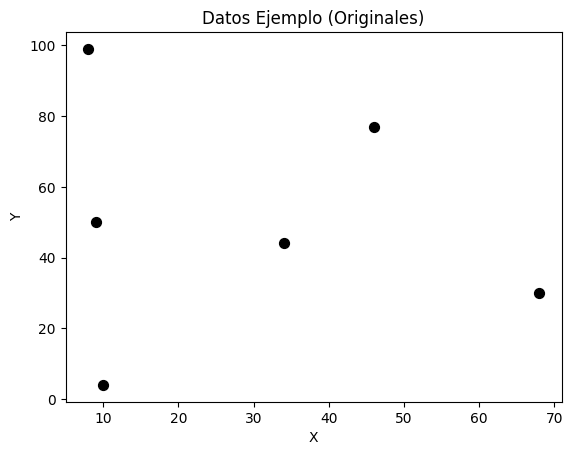

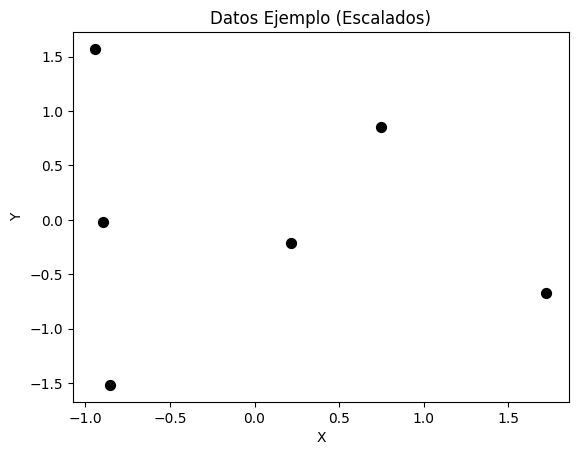

In [56]:
# Visualizacion de los datos
plt.scatter(df['X'], df['Y'], s = 50, c = 'black')
plt.title('Datos Ejemplo (Originales)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

plt.scatter(df_scale['X'], df_scale['Y'], s = 50, c = 'black')
plt.title('Datos Ejemplo (Escalados)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [58]:
# Distancias en escala original
dist1 = pairwise_distances(X=df,  metric ='euclidean').round(2)
dist2 = pairwise_distances(X=df,  metric ='manhattan').round(2)
dist3 = pairwise_distances(X=df,  metric ='mahalanobis').round(2)

print(dist1) # Euclidean
print(dist2) # Manhattan
print(dist3) # Mahalanobis

[[ 0.   95.02 46.65 46.01 81.39 63.56]
 [95.02  0.   60.84 49.01 43.91 91.44]
 [46.65 60.84  0.   25.71 35.11 36.77]
 [46.01 49.01 25.71  0.   45.8  62.3 ]
 [81.39 43.91 35.11 45.8   0.   51.89]
 [63.56 91.44 36.77 62.3  51.89  0.  ]]
[[  0.  97.  64.  47. 109.  84.]
 [ 97.   0.  81.  50.  60. 129.]
 [ 64.  81.   0.  31.  45.  48.]
 [ 47.  50.  31.   0.  64.  79.]
 [109.  60.  45.  64.   0.  69.]
 [ 84. 129.  48.  79.  69.   0.]]
[[0.   2.83 1.64 1.37 2.78 2.58]
 [2.83 0.   1.85 1.46 1.61 3.01]
 [1.64 1.85 0.   1.02 1.15 1.4 ]
 [1.37 1.46 1.02 0.   1.8  2.41]
 [2.78 1.61 1.15 1.8  0.   1.57]
 [2.58 3.01 1.4  2.41 1.57 0.  ]]


In [9]:
# Distancias en datos escalados
dist1 = pairwise_distances(X=df_scale,  metric ='euclidean').round(2)
dist2 = pairwise_distances(X=df_scale,  metric ='manhattan').round(2)
dist3 = pairwise_distances(X=df_scale,  metric ='mahalanobis').round(2)

print(dist1) # Euclidean
print(dist2) # Manhattan
print(dist3) # Mahalanobis

[[0.   3.09 1.68 1.5  2.86 2.71]
 [3.09 0.   2.13 1.59 1.83 3.48]
 [1.68 2.13 0.   1.13 1.2  1.58]
 [1.5  1.59 1.13 0.   1.86 2.7 ]
 [2.86 1.83 1.2  1.86 0.   1.81]
 [2.71 3.48 1.58 2.7  1.81 0.  ]]
[[0.   3.18 2.37 1.54 3.97 3.42]
 [3.18 0.   2.94 1.64 2.4  4.91]
 [2.37 2.94 0.   1.31 1.61 1.97]
 [1.54 1.64 1.31 0.   2.52 3.27]
 [3.97 2.4  1.61 2.52 0.   2.51]
 [3.42 4.91 1.97 3.27 2.51 0.  ]]
[[0.   2.83 1.64 1.37 2.78 2.58]
 [2.83 0.   1.85 1.46 1.61 3.01]
 [1.64 1.85 0.   1.02 1.15 1.4 ]
 [1.37 1.46 1.02 0.   1.8  2.41]
 [2.78 1.61 1.15 1.8  0.   1.57]
 [2.58 3.01 1.4  2.41 1.57 0.  ]]


In [59]:
## Ejemplo datos Mixtos
datos_mixtos = pd.DataFrame({
    "Peso": [68, 73, 67, 64, 76],
    "Estatura": [140, 185, 165, 120, 210],
    "Color_Ojos": ["Verde", "Cafe", "Azul", "Cafe", "Cafe"],
    "Color_Pelo": ["Rubio", "Negro", "Rubio", "Negro", "Negro"],
    "Lateralidad": ["Diestro", "Diestro", "Diestro", "Diestro", "Zurdo"],
    "Sexo": ["F", "M", "M", "F", "M"]
}, index=[1, 2, 3, 4, 5])

datos_mixtos

,Peso,Estatura,Color_Ojos,Color_Pelo,Lateralidad,Sexo
1,68,140,Verde,Rubio,Diestro,F
2,73,185,Cafe,Negro,Diestro,M
3,67,165,Azul,Rubio,Diestro,M
4,64,120,Cafe,Negro,Diestro,F
5,76,210,Cafe,Negro,Zurdo,M


In [60]:
# Calcular la matriz de distancias de Gower
D_G = gower.gower_matrix(datos_mixtos)

print(D_G)

# Matriz de Similaridad
S_G = 1 - D_G 
print(S_G)

[[0.         0.6527778  0.3935185  0.42592594 0.9074074 ]
 [0.6527778  0.         0.4537037  0.41203704 0.25462964]
 [0.3935185  0.4537037  0.         0.625      0.7083334 ]
 [0.42592594 0.41203704 0.625      0.         0.6666667 ]
 [0.9074074  0.25462964 0.7083334  0.6666667  0.        ]]
[[1.         0.3472222  0.6064815  0.57407403 0.0925926 ]
 [0.3472222  1.         0.5462963  0.587963   0.7453704 ]
 [0.6064815  0.5462963  1.         0.375      0.29166663]
 [0.57407403 0.587963   0.375      1.         0.3333333 ]
 [0.0925926  0.7453704  0.29166663 0.3333333  1.        ]]


## Algoritmos Jerarquicos

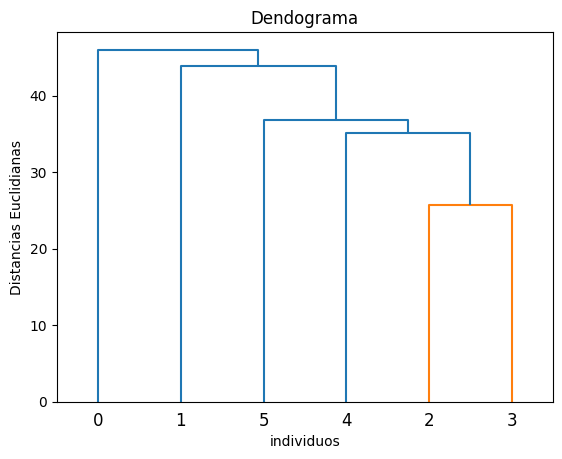

In [61]:
# Creamos el dendograma con el método de enlace simple

dendrogram1 = sch.dendrogram(sch.linkage(df, method = 'single'))
plt.title('Dendograma')
plt.xlabel('individuos')
plt.ylabel('Distancias Euclidianas')
plt.show()

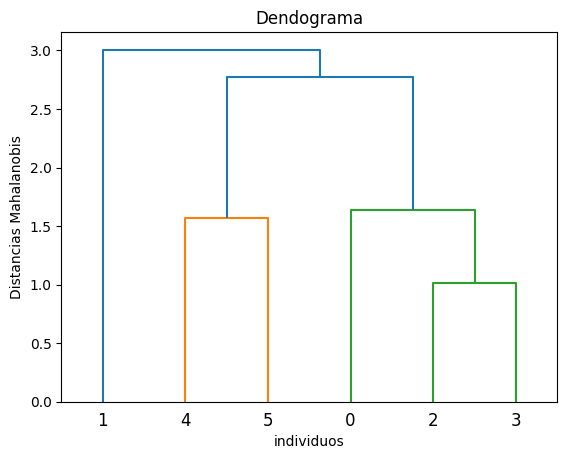

In [62]:
# Creamos el dendograma con el método de enlace completo y distancia de mahalanobis

dendrogram2 = sch.dendrogram(sch.linkage(df, method = 'complete', metric='mahalanobis'))
plt.title('Dendograma')
plt.xlabel('individuos')
plt.ylabel('Distancias Mahalanobis')
plt.show()

In [18]:
dist3

array([[0.  , 2.83, 1.64, 1.37, 2.78, 2.58],
       [2.83, 0.  , 1.85, 1.46, 1.61, 3.01],
       [1.64, 1.85, 0.  , 1.02, 1.15, 1.4 ],
       [1.37, 1.46, 1.02, 0.  , 1.8 , 2.41],
       [2.78, 1.61, 1.15, 1.8 , 0.  , 1.57],
       [2.58, 3.01, 1.4 , 2.41, 1.57, 0.  ]])

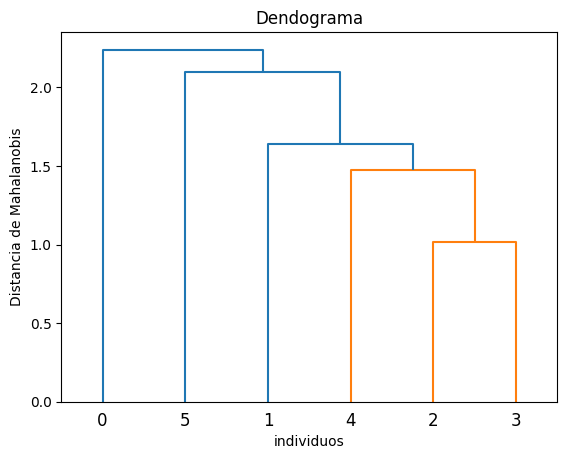

In [63]:
# Creamos el dendograma con el método de enlace promedio

dendrogram3 = sch.dendrogram(sch.linkage(df, method = 'average', metric='mahalanobis'))

plt.title('Dendograma')
plt.xlabel('individuos')
plt.ylabel('Distancia de Mahalanobis')
plt.show()

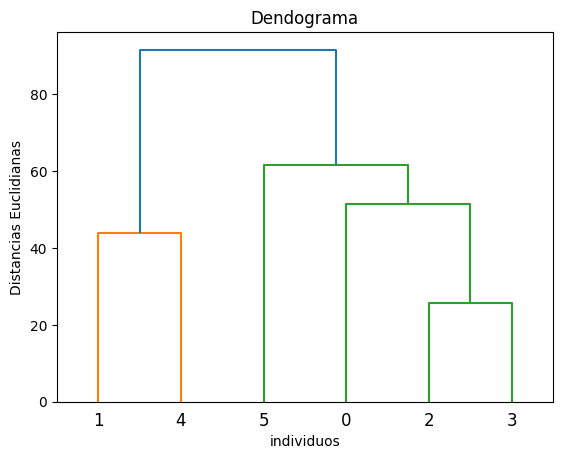

In [64]:
# Creamos el dendograma con el método de enlace ward

dendrogram4 = sch.dendrogram(sch.linkage(df, method = 'ward'))

plt.title('Dendograma')
plt.xlabel('individuos')
plt.ylabel('Distancias Euclidianas')
plt.show()

In [65]:
# Ajustando Clustering Jerárquico al conjunto de datos
hc = AgglomerativeClustering(n_clusters = 2, 
                    metric = 'euclidean', 
                    linkage = 'ward')

y_hc1 = hc.fit_predict(df)
y_hc2 = hc.fit_predict(df_scale)
print(y_hc1)
print(y_hc2)

[0 1 0 0 1 0]
[0 1 1 1 1 0]


In [66]:
df[y_hc1 == 0]

,X,Y
0,10,4
2,34,44
3,9,50
5,68,30


In [67]:
df[y_hc1 == 1]

,X,Y
1,8,99
4,46,77


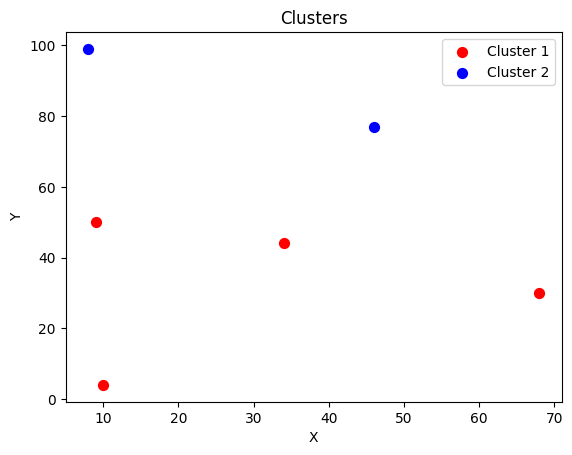

In [68]:
# Visualizacion grafica de los clusters
plt.scatter(df['X'][y_hc1 == 0], df['Y'][y_hc1 == 0], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(df['X'][y_hc1 == 1], df['Y'][y_hc1 == 1], s = 50, c = 'blue', label = 'Cluster 2')

plt.title('Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

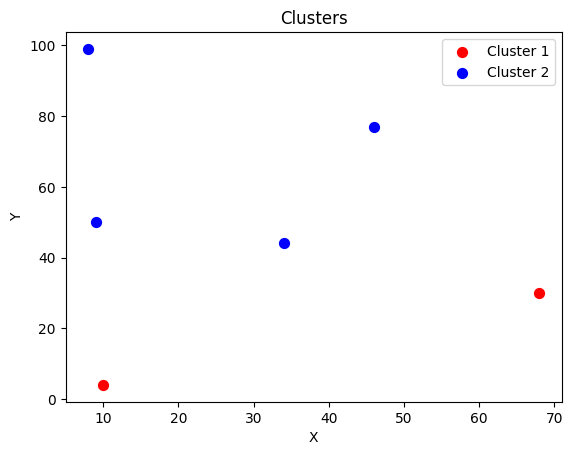

In [69]:
# Visualizacion grafica de los clusters
plt.scatter(df['X'][y_hc2 == 0], df['Y'][y_hc2 == 0], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(df['X'][y_hc2 == 1], df['Y'][y_hc2 == 1], s = 50, c = 'blue', label = 'Cluster 2')

plt.title('Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

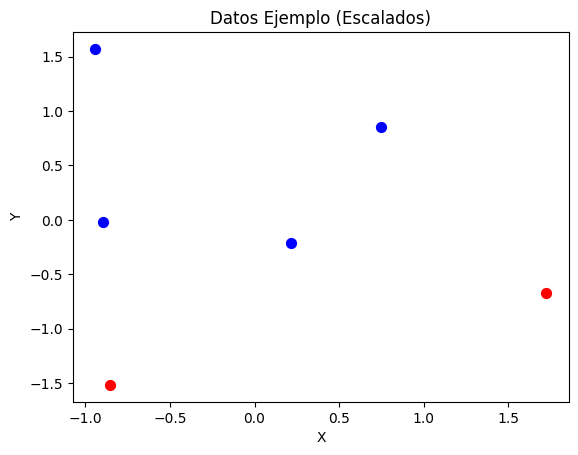

In [70]:
# Visualizacion grafica de los clusters
plt.scatter(df_scale['X'][y_hc2 == 0], df_scale['Y'][y_hc2 == 0], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(df_scale['X'][y_hc2 == 1], df_scale['Y'][y_hc2 == 1], s = 50, c = 'blue', label = 'Cluster 2')


plt.title('Datos Ejemplo (Escalados)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

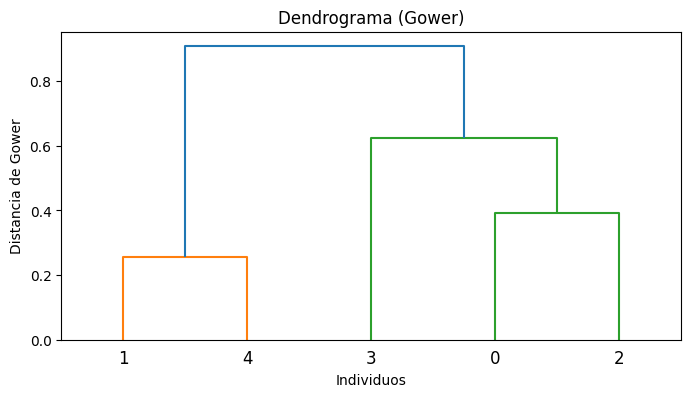

In [71]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

Z = sch.linkage(
    squareform(D_G),
    method="complete"
)

plt.figure(figsize=(8,4))
sch.dendrogram(Z)
plt.title("Dendrograma (Gower)")
plt.xlabel("Individuos")
plt.ylabel("Distancia de Gower")
plt.show()

In [72]:
## Seleccionar 2 grupos
hc = AgglomerativeClustering(
    n_clusters=2,
    metric="precomputed",
    linkage="complete"
)

grupos = hc.fit_predict(D_G)
print(grupos)

[0 1 0 0 1]


## Algoritmos No Jerarquicos

### K-Medias

In [77]:
## Importancia de valores iniciales

km1 = []
for i in range(20):
    kmeans = KMeans(n_clusters=2, init = 'random', n_init=50).fit(df)
    km1.append(kmeans.inertia_)  # inertia_ es equivalente a tot.withinss

km1

[4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75,
 4520.75]

In [78]:
# Método K-medias
kmeans1 = KMeans(n_clusters = 2, init = 'random', n_init=100)
kmeans2 = KMeans(n_clusters = 2, init = 'random', n_init=100)
y_kmeans1 = kmeans1.fit_predict(df)  
y_kmeans2 = kmeans2.fit_predict(df_scale)  

print(kmeans1.inertia_)
print(kmeans2.inertia_)

4520.75
7.178155249635886


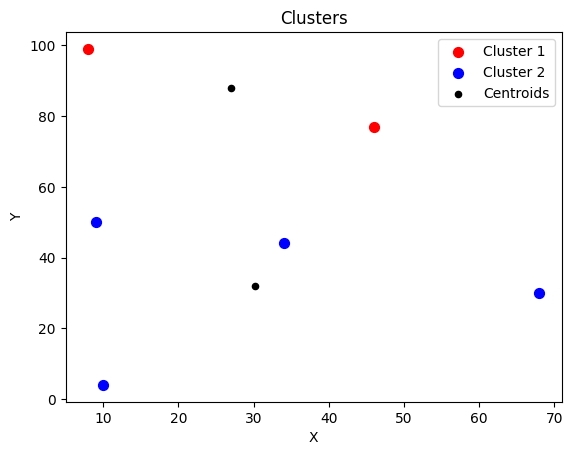

In [80]:
# Visualizacion grafica de los clusters
plt.scatter(df['X'][y_kmeans1 == 0], df['Y'][y_kmeans1 == 0], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(df['X'][y_kmeans1 == 1], df['Y'][y_kmeans1 == 1], s = 50, c = 'blue', label = 'Cluster 2')

plt.scatter(kmeans1.cluster_centers_[:, 0], kmeans1.cluster_centers_[:, 1], s = 20, c = 'black', label = 'Centroids')

plt.title('Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

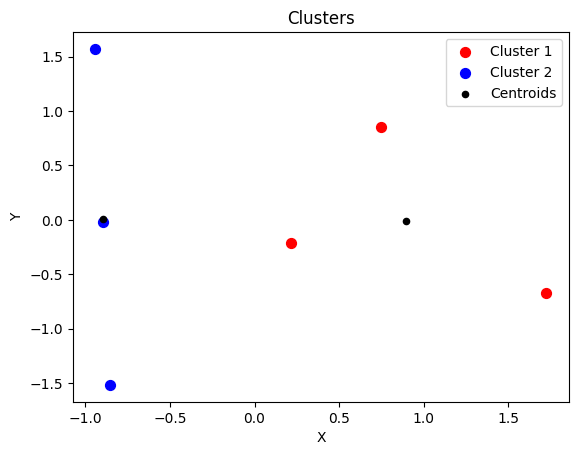

In [35]:
# Visualizacion grafica de los clusters
plt.scatter(df_scale['X'][y_kmeans2 == 0], df_scale['Y'][y_kmeans2 == 0], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(df_scale['X'][y_kmeans2 == 1], df_scale['Y'][y_kmeans2 == 1], s = 50, c = 'blue', label = 'Cluster 2')

plt.scatter(kmeans2.cluster_centers_[:, 0], kmeans2.cluster_centers_[:, 1], s = 20, c = 'black', label = 'Centroids')

plt.title('Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

### K-Medoids

In [82]:
# K-Medois
from sklearn_extra.cluster import KMedoids

KMobj = KMedoids(n_clusters=2, method='pam', metric='manhattan').fit(df)
y_KMD = KMobj.labels_
print(y_KMD)

[0 1 0 0 0 0]


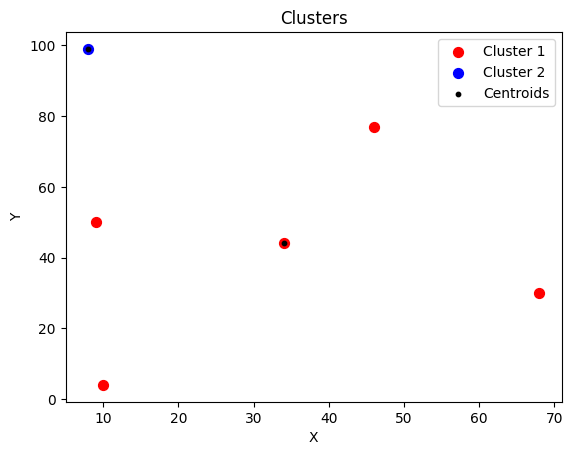

In [83]:
# Visualizacion grafica de los clusters
plt.scatter(df['X'][y_KMD == 0], df['Y'][y_KMD == 0], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(df['X'][y_KMD == 1], df['Y'][y_KMD == 1], s = 50, c = 'blue', label = 'Cluster 2')

plt.scatter(KMobj.cluster_centers_[:, 0], KMobj.cluster_centers_[:, 1], s = 10, c = 'black', label = 'Centroids')

plt.title('Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [84]:
## Ejemplo datos mixtos

KMobj = KMedoids(
    n_clusters=2,
    metric='precomputed',
    method='pam').fit(D_G)

y_KMD_mixtos = KMobj.labels_
print(y_KMD_mixtos)

[1 0 1 0 0]


# Ejemplo Completo

In [86]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn_extra.cluster import KMedoids
import pandas as pd

# Cargar datos
wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names)

y_real = wine.target
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [44]:
X.tail()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0


<Axes: >

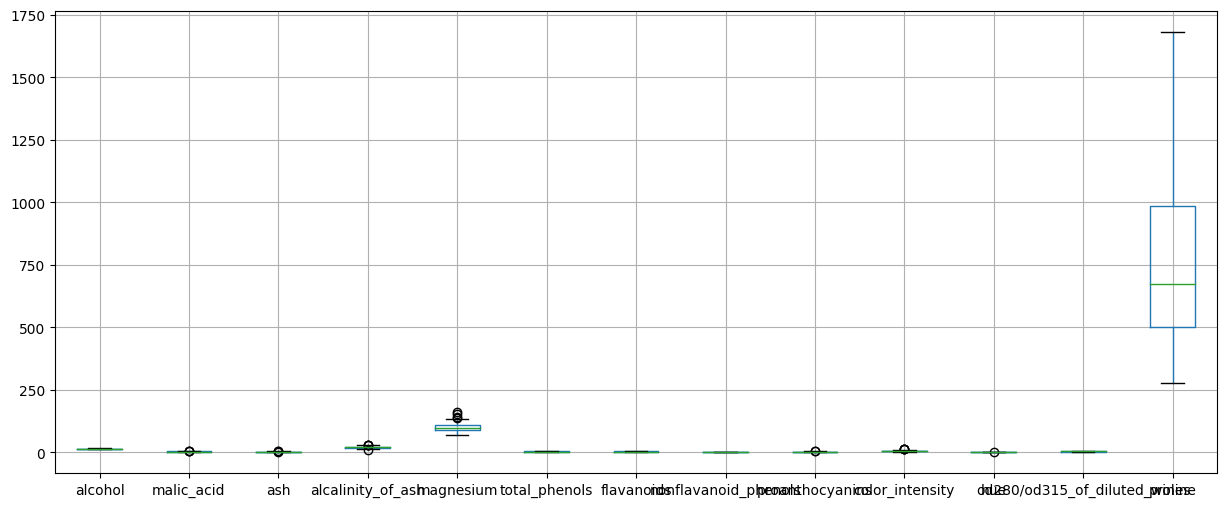

In [94]:
plt.figure(figsize=(15,6))
X.boxplot()

In [93]:
# Escalamiento
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

In [48]:
# Clustering jerárquico
hc = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="ward"
)

y_hc = hc.fit_predict(X_scale)

# K-means
km = KMeans(
    n_clusters=3,
    random_state=123,
    n_init=20
)

y_km = km.fit_predict(X_scale)

# K-medoids
kmd = KMedoids(
    n_clusters=3,
    metric="euclidean",
    method="pam",
    random_state=123
)

y_kmd = kmd.fit_predict(X_scale)

In [50]:
# Comparación entre metodos
pd.crosstab(y_hc, y_km, rownames=["Cluster Jerarquico"], colnames=["Cluster K-means"])

Cluster K-means,0,1,2
Cluster Jerarquico,,,
0,0,1,57
1,51,0,5
2,0,61,3


In [52]:
# Comparación descriptiva con las clases reales
pd.crosstab(y_real, y_hc, rownames=["Clase real"], colnames=["Cluster Jerarquíco"])

Cluster Jerarquíco,0,1,2
Clase real,,,
0,0,0,59
1,58,8,5
2,0,48,0


In [53]:
# Comparación descriptiva con las clases reales
pd.crosstab(y_real, y_km, rownames=["Clase real"], colnames=["Cluster K-means"])

Cluster K-means,0,1,2
Clase real,,,
0,0,59,0
1,3,3,65
2,48,0,0


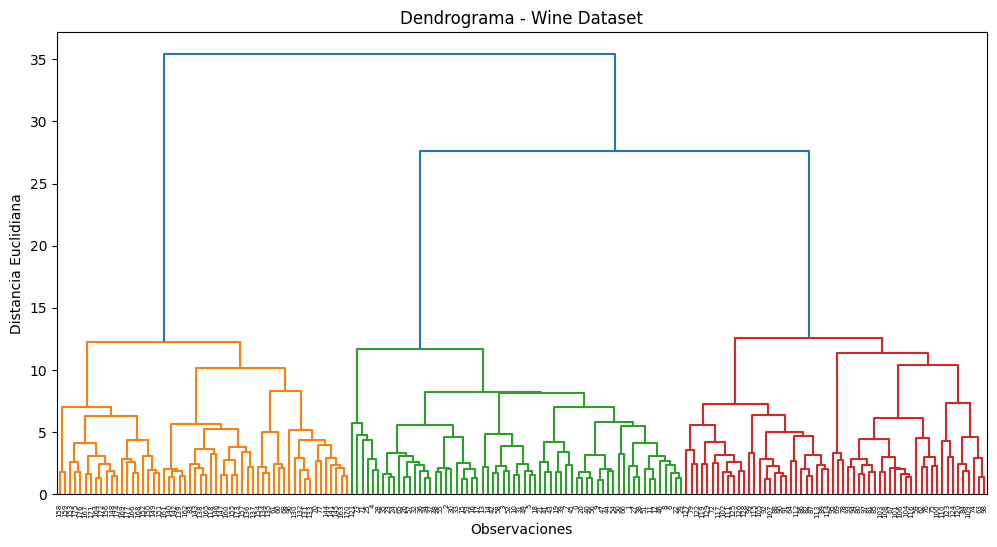

In [88]:
# Dendrograma
plt.figure(figsize=(12,6))

sch.dendrogram(
    sch.linkage(X_scale, method='ward')
)

plt.title('Dendrograma - Wine Dataset')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')
plt.show()

## Comentario final

Este ejemplo muestra que, al trabajar con datos reales de mayor dimensión, el escalamiento de las variables se vuelve fundamental. 
Además, aunque los métodos de clustering no utilizan las clases reales durante el ajuste, estas pueden servir posteriormente como referencia externa para interpretar los grupos encontrados.

En este caso, los algoritmos no buscan predecir el tipo de vino, sino descubrir si las mediciones físico-químicas contienen una estructura natural de agrupamiento.